<a href="https://colab.research.google.com/github/ManoelVictor99/CNN/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# CNN


# Etapa 1: Importação das bibliotecas

In [1]:
# Importação das bibliotecas necessárias
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.callbacks import ModelCheckpoint

# Montar o Google Drive para acessar a pasta com as fotos
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Etapa 2: Carregamento da base de dados

In [2]:
base_dir = '/content/drive/MyDrive/Colab Notebooks/CNN/Departamento médico/Departamento médico'

dataset_dir = f'{base_dir}/Dataset'
test_dir = f'{base_dir}/Test'

batch_size = 32
img_height = 150
img_width = 150

In [3]:


# 1. Carregando dados de Treinamento (80% da pasta Dataset)
train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 2. Carregando dados de Validação (20% da pasta Dataset)
val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 3. Carregando dados de Teste (100% da pasta Test)
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 532 files belonging to 4 classes.
Using 426 files for training.
Found 532 files belonging to 4 classes.
Using 106 files for validation.
Found 40 files belonging to 4 classes.


In [4]:
# Dicionário mapeando os números das pastas para os nomes reais das classes
nomes_classes = {
    0: 'Covid-19',
    1: 'Normal',
    2: 'Pneumonia Viral',
    3: 'Pneumonia Bacteriana'
}
print("Classes carregadas:", train_ds.class_names)

Classes carregadas: ['0', '1', '2', '3']


# Etapa 3: Criação da Arquitetura do Modelo

In [5]:

modelo_cnn = models.Sequential()

modelo_cnn.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# 1ª Camada Convolucional e Pooling
modelo_cnn.add(layers.Conv2D(16, (3, 3), activation='relu'))
modelo_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))

# 2ª Camada Convolucional e Pooling
modelo_cnn.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))

# 3ª Camada Convolucional e Pooling
modelo_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Achatamento (Flatten)
modelo_cnn.add(layers.Flatten())

# Camadas Conectadas
modelo_cnn.add(layers.Dense(128, activation='relu'))
modelo_cnn.add(layers.Dense(4, activation='softmax'))

modelo_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,391,716 (9.12 MB)

 Trainable params: 2,391,716 (9.12 MB)

 Non-trainable params: 0 (0.00 B)

# Etapa 4: Compilação

In [6]:
# Compilação
modelo_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Checkpoint para salvar o melhor modelo com base na menor perda de validação
filepath = "melhor_modelo_raios_x.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
callbacks_list = [checkpoint]

# Etapa 5: Treinamento do Modelo

In [7]:
epochs = 20

history = modelo_cnn.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=callbacks_list
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.3195 - loss: 1.7057
Epoch 1: val_loss improved from None to 1.24409, saving model to melhor_modelo_raios_x.keras

Epoch 1: finished saving model to melhor_modelo_raios_x.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 573ms/step - accuracy: 0.3756 - loss: 1.5045 - val_accuracy: 0.4340 - val_loss: 1.2441
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5952 - loss: 1.0799
Epoch 2: val_loss improved from 1.24409 to 0.91770, saving model to melhor_modelo_raios_x.keras

Epoch 2: finished saving model to melhor_modelo_raios_x.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 331ms/step - accuracy: 0.6643 - loss: 0.9411 - val_accuracy: 0.5755 - val_loss: 0.9177
Epoch 3/20
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.7649 - loss: 0.5766
Epoch 3: val_loss improved from 0.91770 to 0.72472, saving model to melhor_modelo_raios_x.keras

Epoch 3: finished saving model to melhor_modelo_raios_x.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 45

# Etapa 6: Gráficos e Resultados

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step - accuracy: 0.7500 - loss: 1.1735

 Acurácia nos dados de Teste: 0.7500


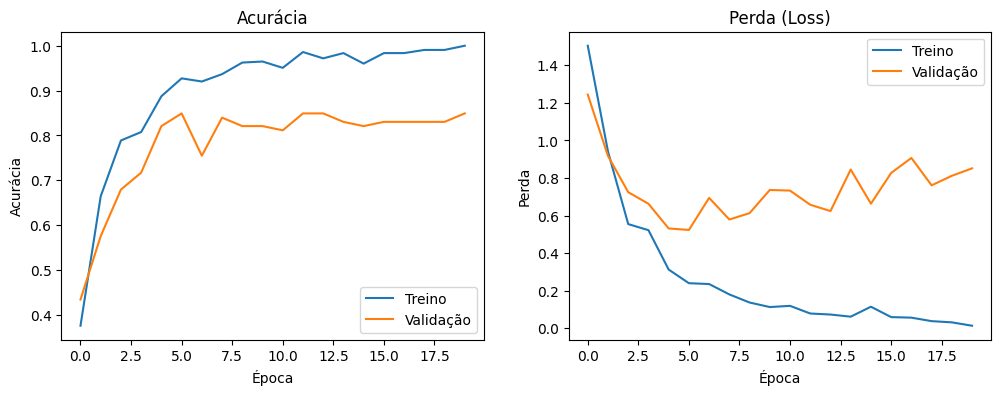

In [8]:
# 1. Avaliação com a pasta de Teste
score = modelo_cnn.evaluate(test_ds)
print(f'\n Acurácia nos dados de Teste: {score[1]:.4f}')

# 2. Gráficos de Treinamento
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='upper right')

plt.show()

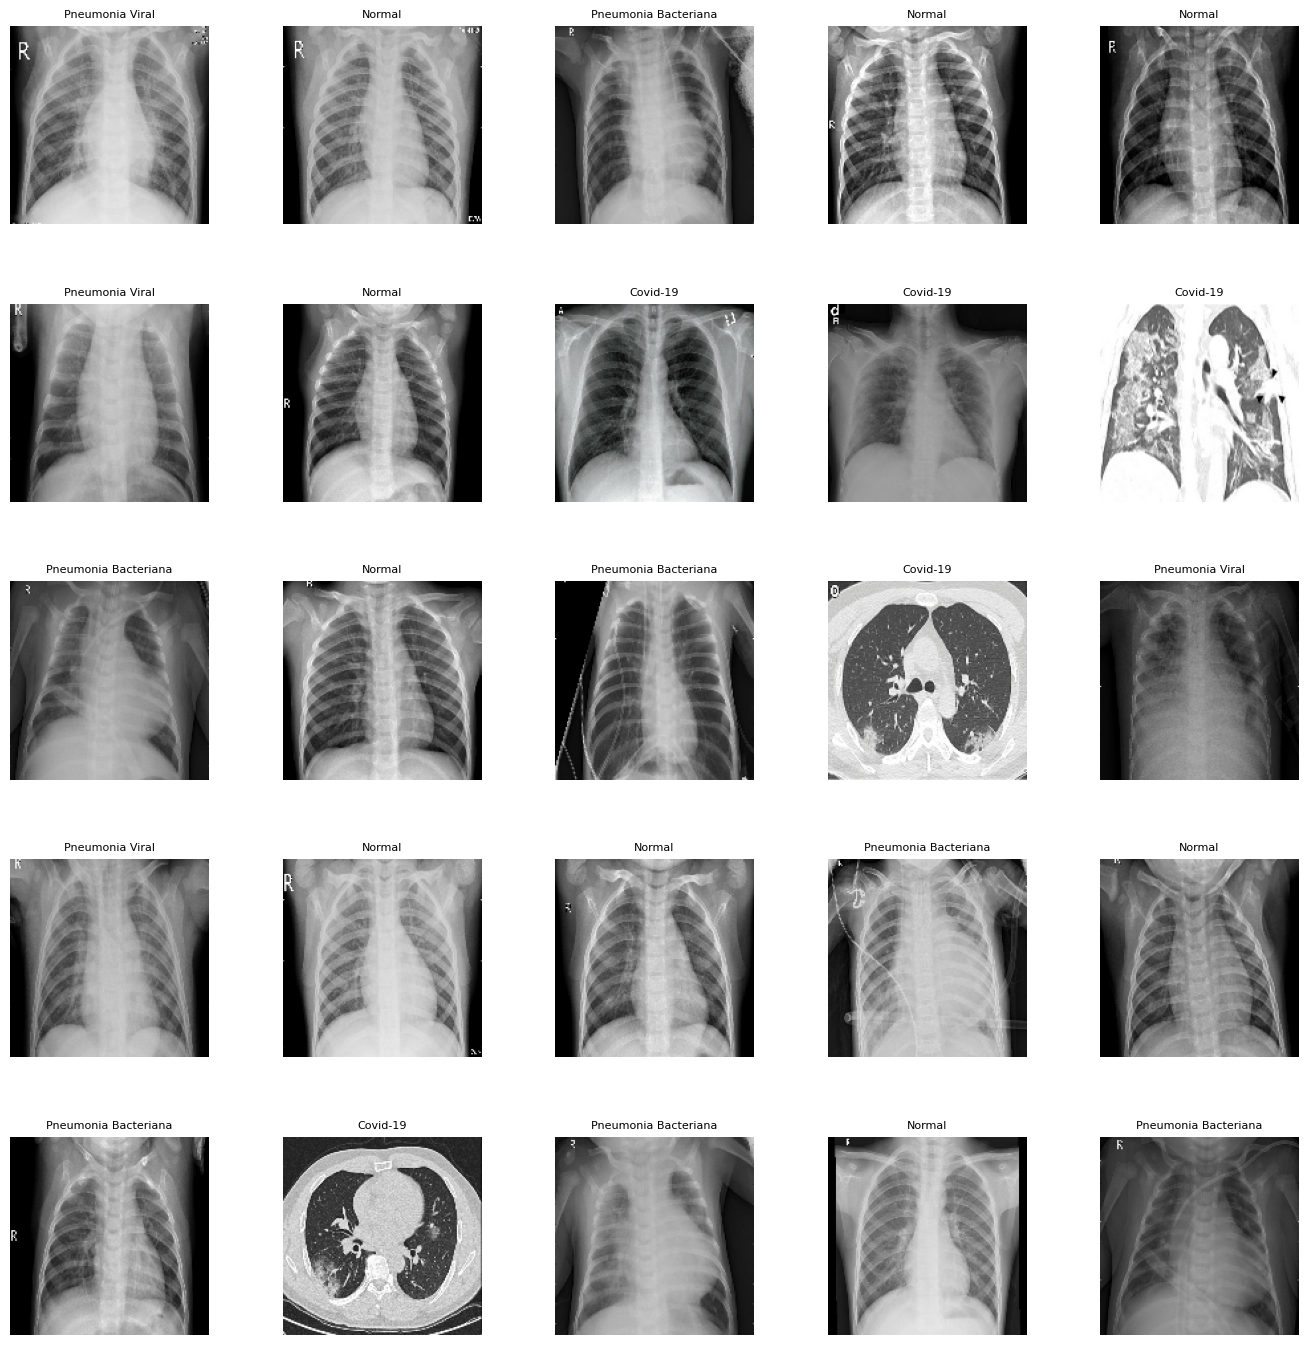

In [9]:
W_grid = 5
L_grid = 5

fig, axes = plt.subplots(L_grid, W_grid, figsize=(17, 17))
axes = axes.ravel()

# 1. Extraindo imagens e rótulos
imagens = []
rotulos = []

for img, label in train_ds.unbatch().take(W_grid * L_grid):
    imagens.append(img.numpy().astype("uint8"))
    rotulos.append(label.numpy())

# 2. Preenchendo o Grid
for i in np.arange(0, W_grid * L_grid):
    axes[i].imshow(imagens[i])
    nome_da_classe = nomes_classes[rotulos[i]]
    axes[i].set_title(nome_da_classe, fontsize=8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


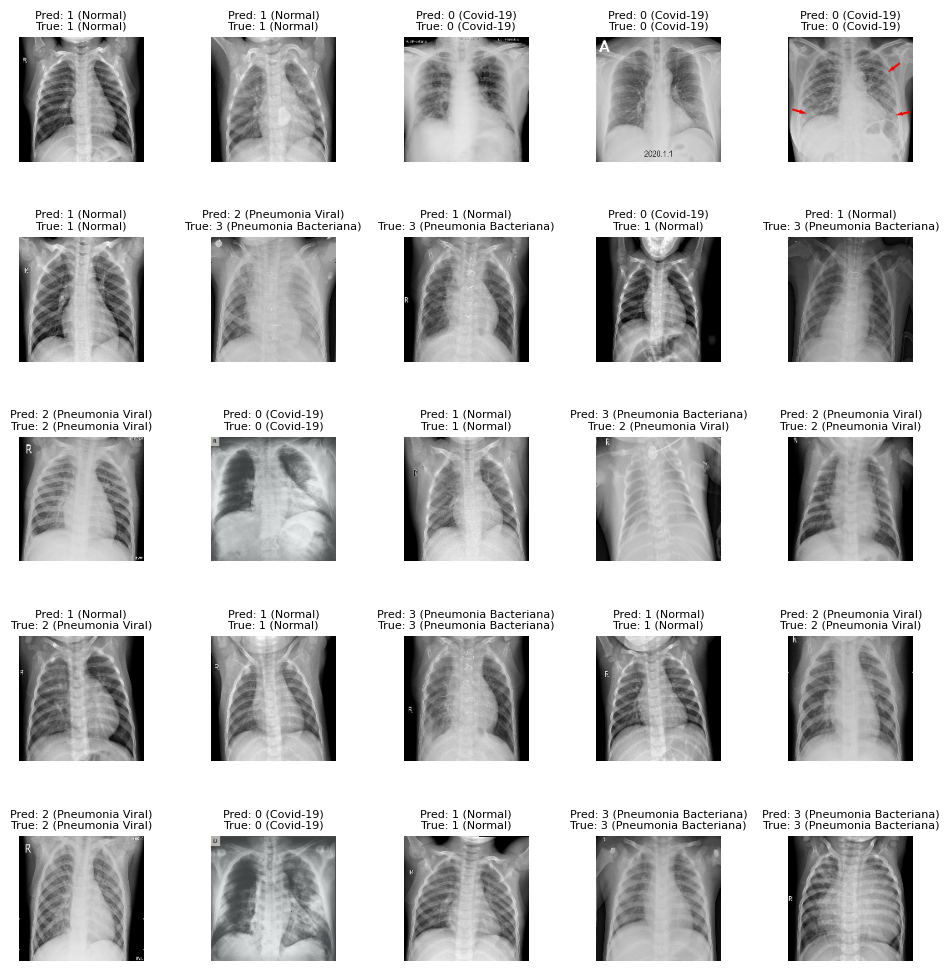

In [10]:

# 1. Extrair um lote de imagens do dataset de teste
for imagens_teste, rotulos_teste in test_ds.take(1):
    X_test_batch = imagens_teste.numpy()
    y_test_batch = rotulos_teste.numpy()
    break

# 2. Gerar as previsões usando o modelo treinado
previsoes = modelo_cnn.predict(X_test_batch)
predicted_classes = np.argmax(previsoes, axis=1)

# 3. Plotagem do Grid 5x5
W_grid = 5
L_grid = 5

fig, axes = plt.subplots(L_grid, W_grid, figsize=(12, 12))
axes = axes.ravel()

for i in np.arange(0, W_grid * L_grid):
    axes[i].imshow(X_test_batch[i].astype("uint8"))
    pred_nome = nomes_classes[int(predicted_classes[i])]
    real_nome = nomes_classes[int(y_test_batch[i])]

    axes[i].set_title(f"Pred: {predicted_classes[i]} ({pred_nome})\nTrue: {y_test_batch[i]} ({real_nome})", fontsize=8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.6)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


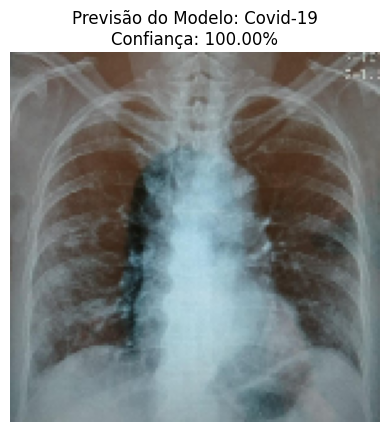

In [11]:
caminho_imagem = '/content/drive/MyDrive/Colab Notebooks/CNN/Departamento médico/Departamento médico/Screenshot_1.jpg'

# 1. Carregar a imagem e redimensionar para 150x150
img = tf.keras.utils.load_img(caminho_imagem, target_size=(150, 150))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# 2. Fazer a previsão com o modelo treinado
previsoes = modelo_cnn.predict(img_array)
classe_prevista = np.argmax(previsoes[0])
confianca = 100 * np.max(previsoes[0])
nome_previsto = nomes_classes[classe_prevista]

# 3. Exibir a imagem e o resultado da previsão
plt.imshow(img)
plt.title(f"Previsão do Modelo: {nome_previsto}\nConfiança: {confianca:.2f}%")
plt.axis('off')
plt.show()